# Twitter Sentiment Analysis — Detecting Offensive Tweets

**Author:** *(add your name)* &nbsp;|&nbsp; **Type:** NLP / Binary Text Classification &nbsp;|&nbsp; **Stack:** scikit-learn, NLTK, imbalanced-learn

## Project overview

This project builds a machine learning pipeline that classifies tweets as **normal (0)** or **offensive/hate speech (1)**. The raw dataset is highly imbalanced — roughly **93% normal tweets vs. 7% offensive tweets** — which is the central challenge of this project and the main thing that separates a "naive" solution from a genuinely useful one.

A model that always predicts "normal" would already score ~93% accuracy while being completely useless, since it would never catch a single offensive tweet. So instead of optimizing for accuracy, this notebook is built around **precision, recall, F1-score, and ROC-AUC for the minority (offensive) class**, and explicitly handles the imbalance with **class weighting and SMOTE oversampling**.

### What this notebook covers
1. **Exploratory Data Analysis (EDA)** — class balance, tweet length, hashtags/mentions, word clouds
2. **Feature engineering** — structural features (length, punctuation, hashtag/mention counts) extracted *before* cleaning
3. **Text preprocessing** — URL/mention/hashtag stripping, lemmatization (kept over stemming for cleaner, more interpretable tokens), stopword removal
4. **Feature extraction** — TF-IDF with unigrams + bigrams
5. **Handling class imbalance** — `class_weight='balanced'` baseline vs. SMOTE-resampled training data
6. **Model comparison & tuning** — Logistic Regression, Linear SVM, and Naive Bayes, with `GridSearchCV` hyperparameter tuning
7. **Evaluation** — confusion matrix, classification report, ROC curve, precision-recall curve (the metric that matters most here)
8. **Error analysis** — inspecting misclassified tweets to understand model limitations
9. **Inference** — a reusable `predict_sentiment()` function for new, unseen text

> **Note on the dataset file:** This notebook expects a `twitter.csv` file with three columns — `id`, `label`, `tweet` — in the same directory as the notebook. If you're running this against the original dataset, no changes are needed.

## 1. Imports & Setup

In [ ]:
import re
import string
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score,
    roc_curve, precision_recall_curve, ConfusionMatrixDisplay
)

from imblearn.over_sampling import SMOTE

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

## 2. Download NLTK Resources

In [2]:
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)
print("NLTK resources ready.")

NLTK resources ready.


## 3. Load the Dataset

The dataset has three columns:
- **id** — unique tweet identifier
- **label** — `0` = normal tweet, `1` = offensive/hate speech
- **tweet** — the raw tweet text

In [3]:
data = pd.read_csv('twitter.csv', encoding='ISO-8859-1')
print(f"Shape: {data.shape}")
data.head()

Shape: (31962, 3)


,id,label,tweet
0,1,0,@user when a father is dysfunctional and is s...
1,2,0,@user @user thanks for #lyft credit i can't us...
2,3,0,bihday your majesty
3,4,0,#model i love u take with u all the time in ...
4,5,0,factsguide: society now #motivation


In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31962 entries, 0 to 31961
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   id      31962 non-null  int64 
 1   label   31962 non-null  int64 
 2   tweet   31962 non-null  object
dtypes: int64(2), object(1)
memory usage: 749.2+ KB


In [5]:
# Check for missing values and duplicate tweets
print("Missing values:\n", data.isnull().sum())
print("\nDuplicate tweets:", data['tweet'].duplicated().sum())

Missing values:
 id       0
label    0
tweet    0
dtype: int64

Duplicate tweets: 2432


In [6]:
# Drop exact duplicate tweets (keeps the dataset clean and prevents leakage between
# train/test splits if the same tweet appears more than once)
before = len(data)
data = data.drop_duplicates(subset='tweet').reset_index(drop=True)
print(f"Removed {before - len(data)} duplicate rows. New shape: {data.shape}")

Removed 2432 duplicate rows. New shape: (29530, 3)


## 4. Exploratory Data Analysis (EDA)

Before touching the text, it's important to understand the structure of the data — especially the **class imbalance**, since that drives almost every modeling decision later in the notebook.

Class counts:
 label
0    27517
1     2013
Name: count, dtype: int64

Class percentages:
 label
0    93.18
1     6.82
Name: proportion, dtype: float64


C:\Users\btech\AppData\Local\Temp\ipykernel_20988\1058265124.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='label', data=data, ax=axes[0], palette=['#4C72B0', '#C44E52'])
C:\Users\btech\AppData\Local\Temp\ipykernel_20988\1058265124.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(['Normal (0)', 'Offensive (1)'])


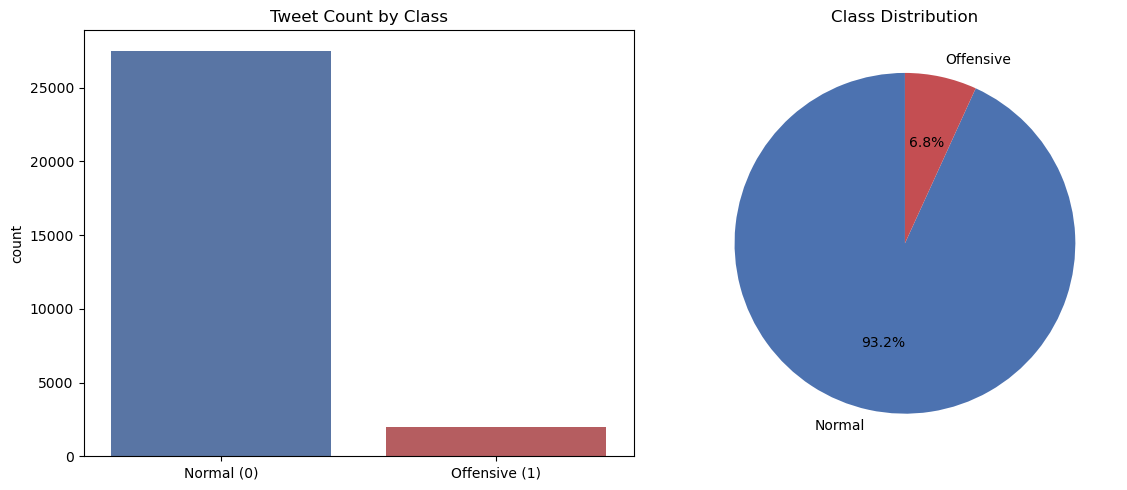


Imbalance ratio: 13.7 normal tweets for every 1 offensive tweet.
This confirms accuracy alone would be a misleading metric — see Section 8.


In [7]:
label_counts = data['label'].value_counts()
label_pct = data['label'].value_counts(normalize=True) * 100

print("Class counts:\n", label_counts)
print("\nClass percentages:\n", label_pct.round(2))

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.countplot(x='label', data=data, ax=axes[0], palette=['#4C72B0', '#C44E52'])
axes[0].set_title('Tweet Count by Class')
axes[0].set_xticklabels(['Normal (0)', 'Offensive (1)'])
axes[0].set_xlabel('')

axes[1].pie(label_counts, labels=['Normal', 'Offensive'], autopct='%1.1f%%',
            colors=['#4C72B0', '#C44E52'], startangle=90)
axes[1].set_title('Class Distribution')

plt.tight_layout()
plt.show()

imbalance_ratio = label_counts[0] / label_counts[1]
print(f"\nImbalance ratio: {imbalance_ratio:.1f} normal tweets for every 1 offensive tweet.")
print("This confirms accuracy alone would be a misleading metric — see Section 8.")

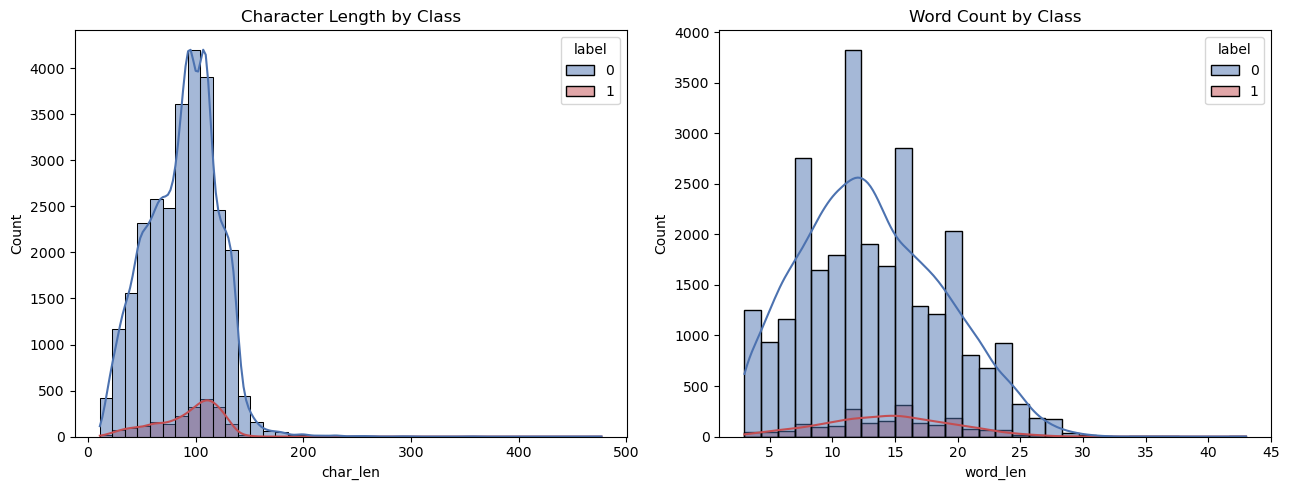

In [8]:
# Tweet length distribution by class
data['char_len'] = data['tweet'].astype(str).apply(len)
data['word_len'] = data['tweet'].astype(str).apply(lambda x: len(x.split()))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.histplot(data=data, x='char_len', hue='label', bins=40, kde=True, ax=axes[0], palette=['#4C72B0', '#C44E52'])
axes[0].set_title('Character Length by Class')

sns.histplot(data=data, x='word_len', hue='label', bins=30, kde=True, ax=axes[1], palette=['#4C72B0', '#C44E52'])
axes[1].set_title('Word Count by Class')

plt.tight_layout()
plt.show()

C:\Users\btech\AppData\Local\Temp\ipykernel_20988\1949375277.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(counts), y=list(tags), palette='viridis')


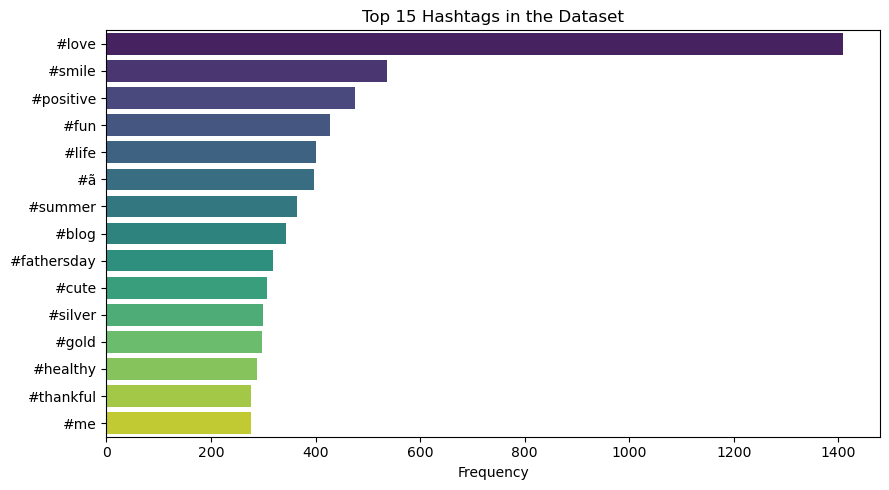

In [9]:

import re
from collections import Counter

def extract_hashtags(text):
    return re.findall(r'#\w+', str(text).lower())

all_hashtags = data['tweet'].apply(extract_hashtags).sum()
top_hashtags = Counter(all_hashtags).most_common(15)

if top_hashtags:
    tags, counts = zip(*top_hashtags)
    plt.figure(figsize=(9, 5))
    sns.barplot(x=list(counts), y=list(tags), palette='viridis')
    plt.title('Top 15 Hashtags in the Dataset')
    plt.xlabel('Frequency')
    plt.tight_layout()
    plt.show()
else:
    print("No hashtags found in this sample.")

In [11]:
!pip install wordcloud

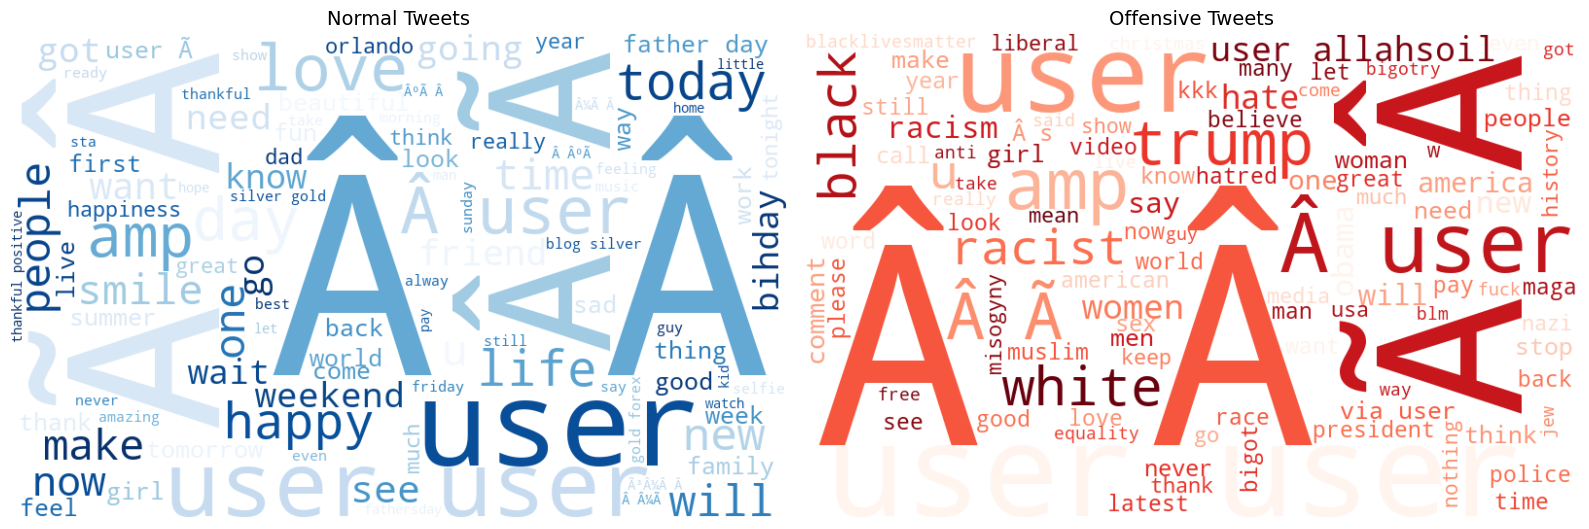

In [12]:
# Word clouds give a fast, intuitive read on vocabulary differences between classes
from wordcloud import WordCloud

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

for ax, lbl, title, cmap in zip(
    axes, [0, 1], ['Normal Tweets', 'Offensive Tweets'], ['Blues', 'Reds']
):
    text_blob = ' '.join(data.loc[data['label'] == lbl, 'tweet'].astype(str))
    wc = WordCloud(width=800, height=500, background_color='white',
                   colormap=cmap, max_words=100).generate(text_blob)
    ax.imshow(wc, interpolation='bilinear')
    ax.set_title(title, fontsize=14)
    ax.axis('off')

plt.tight_layout()
plt.show()

## 5. Feature Engineering (Structural Features)

Before the raw text gets cleaned and reduced down to lemmatized tokens, we extract a handful of **structural features** from the *original* tweet. These capture signal that text cleaning would otherwise throw away — for example, ALL-CAPS ratio and excessive punctuation are often associated with aggressive or offensive tone, while hashtag/mention counts say something about how the tweet is constructed.

These engineered features aren't fed into the TF-IDF model directly in this notebook (TF-IDF text features are the primary signal), but they're valuable for **EDA, reporting, and as an extension** — interview-ready proof that you understand feature engineering beyond just vectorizing text. We'll also briefly demonstrate combining them with TF-IDF in Section 9.

In [13]:
def extract_structural_features(df, text_col='tweet'):
    df = df.copy()
    text = df[text_col].astype(str)

    df['char_count'] = text.apply(len)
    df['word_count'] = text.apply(lambda x: len(x.split()))
    df['avg_word_len'] = df['char_count'] / df['word_count'].replace(0, 1)
    df['hashtag_count'] = text.apply(lambda x: len(re.findall(r'#\w+', x)))
    df['mention_count'] = text.apply(lambda x: len(re.findall(r'@\w+', x)))
    df['exclaim_count'] = text.apply(lambda x: x.count('!'))
    df['question_count'] = text.apply(lambda x: x.count('?'))
    df['uppercase_ratio'] = text.apply(
        lambda x: sum(1 for c in x if c.isupper()) / max(len(x), 1)
    )
    df['punctuation_count'] = text.apply(
        lambda x: sum(1 for c in x if c in string.punctuation)
    )
    return df

data = extract_structural_features(data)
structural_cols = ['char_count', 'word_count', 'avg_word_len', 'hashtag_count',
                    'mention_count', 'exclaim_count', 'question_count',
                    'uppercase_ratio', 'punctuation_count']
data[structural_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
char_count,29530.0,88.412665,32.178983,11.0,65.000000,92.0,111.000000,477.000000
word_count,29530.0,13.262479,5.562304,3.0,9.000000,13.0,17.000000,43.000000
avg_word_len,29530.0,7.080750,2.743976,2.0,5.708333,6.5,7.714286,155.666667
hashtag_count,29530.0,2.365154,2.526486,0.0,0.000000,2.0,4.000000,20.000000
mention_count,29530.0,0.582628,1.002704,0.0,0.000000,0.0,1.000000,11.000000
exclaim_count,29530.0,0.424958,1.068899,0.0,0.000000,0.0,0.000000,58.000000
question_count,29530.0,0.081206,0.369301,0.0,0.000000,0.0,0.000000,12.000000
uppercase_ratio,29530.0,0.030419,0.060315,0.0,0.000000,0.0,0.033333,0.471092
punctuation_count,29530.0,5.323129,3.303958,0.0,3.000000,5.0,7.000000,77.000000


C:\Users\btech\AppData\Local\Temp\ipykernel_20988\3880782817.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='label', y=col, data=data, ax=ax, palette=['#4C72B0', '#C44E52'])
C:\Users\btech\AppData\Local\Temp\ipykernel_20988\3880782817.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Normal', 'Offensive'])
C:\Users\btech\AppData\Local\Temp\ipykernel_20988\3880782817.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='label', y=col, data=data, ax=ax, palette=['#4C72B0', '#C44E52'])
C:\Users\btech\AppData\Local\Temp\ipykernel_20988\3880782817.py:8: UserWarning: set_ticklabels(

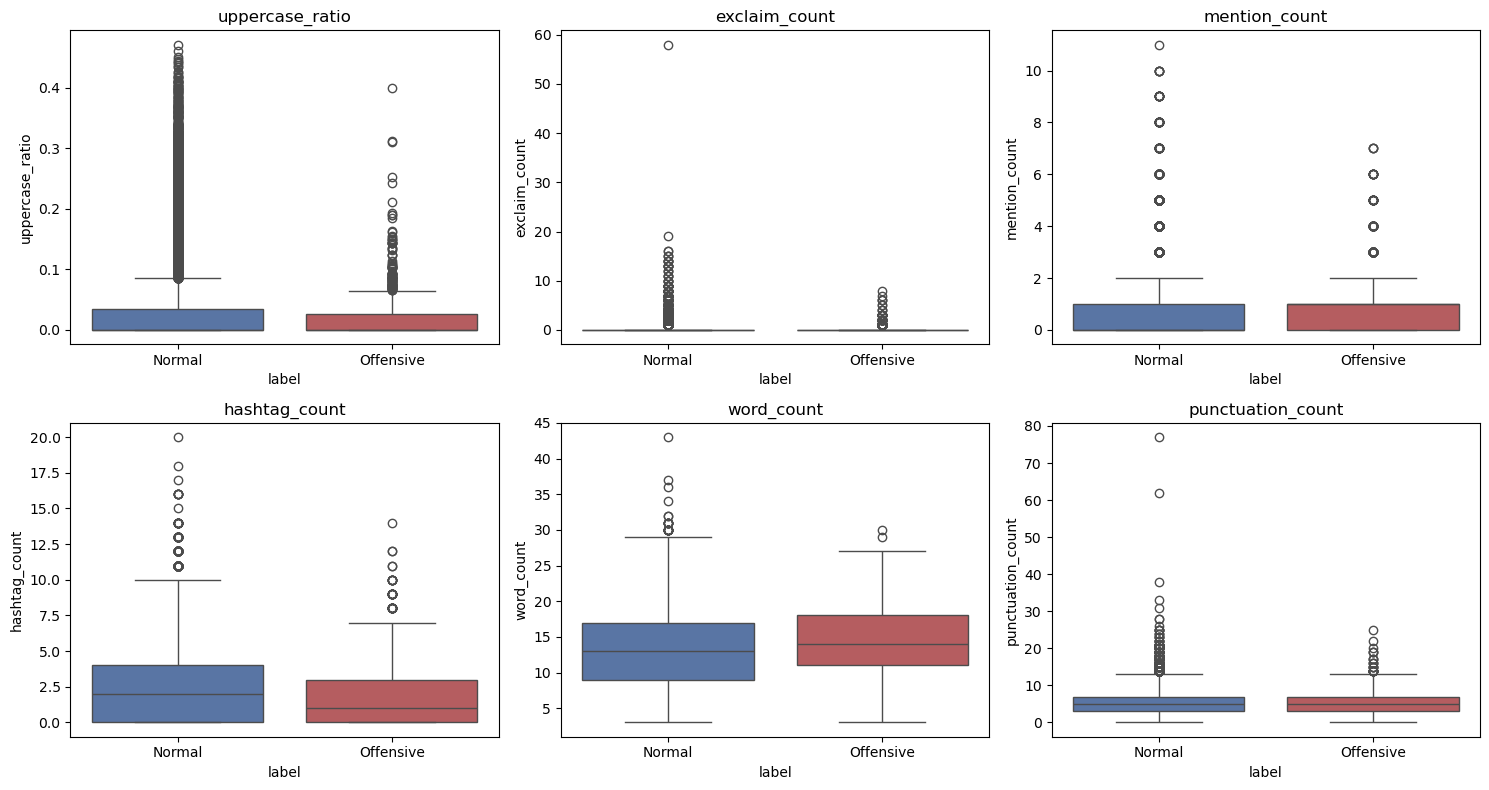

In [14]:
# Compare structural features across classes — do offensive tweets look different structurally?
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
compare_cols = ['uppercase_ratio', 'exclaim_count', 'mention_count',
                 'hashtag_count', 'word_count', 'punctuation_count']

for ax, col in zip(axes.flat, compare_cols):
    sns.boxplot(x='label', y=col, data=data, ax=ax, palette=['#4C72B0', '#C44E52'])
    ax.set_xticklabels(['Normal', 'Offensive'])
    ax.set_title(col)

plt.tight_layout()
plt.show()

## 6. Text Preprocessing

The original version of this notebook used `PorterStemmer`, which is fast but produces crude, non-words (`"dysfunct"`, `"majesti"`, `"factsguid"`). This rewrite switches to **`WordNetLemmatizer`**, which maps words to valid dictionary forms (`"running"` → `"run"`, `"better"` → `"good"`-adjacent lemma rules), producing cleaner, more interpretable tokens — useful both for the model's vocabulary and for any reporting/word clouds shown to stakeholders.

The cleaning function also explicitly strips **URLs**, **@mentions**, and the `#` symbol (keeping the hashtag word itself, since hashtag words often carry sentiment, e.g. `#hate`, `#blessed`).

In [15]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'http\S+|www\.\S+', ' ', text)      # URLs
    text = re.sub(r'@\w+', ' ', text)                  # @mentions
    text = re.sub(r'#', ' ', text)                     # keep hashtag word, drop the symbol
    text = re.sub(r'[^a-z\s]', ' ', text)              # punctuation / numbers / emojis
    text = re.sub(r'\s+', ' ', text).strip()           # collapse whitespace

    tokens = text.split()
    tokens = [
        lemmatizer.lemmatize(word)
        for word in tokens
        if word not in stop_words and len(word) > 2
    ]
    return ' '.join(tokens)

# Quick before/after sanity check
sample = data['tweet'].iloc[0]
print("BEFORE:", sample)
print("AFTER :", clean_text(sample))

BEFORE:  @user when a father is dysfunctional and is so selfish he drags his kids into his dysfunction.   #run
AFTER : father dysfunctional selfish drag kid dysfunction run


AFTER : new job absolutely wonderful today goodvibes


In [48]:
LABELS = {
    0: "Normal",
    1: "Offensive"
}

In [16]:
data['clean_tweet'] = data['tweet'].apply(clean_text)
data[['tweet', 'clean_tweet']].head(10)

,tweet,clean_tweet
0,@user when a father is dysfunctional and is s...,father dysfunctional selfish drag kid dysfunct...
1,@user @user thanks for #lyft credit i can't us...,thanks lyft credit use cause offer wheelchair ...
2,bihday your majesty,bihday majesty
3,#model i love u take with u all the time in ...,model love take time
4,factsguide: society now #motivation,factsguide society motivation
5,[2/2] huge fan fare and big talking before the...,huge fan fare big talking leave chaos pay disp...
6,@user camping tomorrow @user @user @user @use...,camping tomorrow danny
7,the next school year is the year for exams.Ã°Â...,next school year year exam think school exam h...
8,we won!!! love the land!!! #allin #cavs #champ...,love land allin cavs champion cleveland clevel...
9,@user @user welcome here ! i'm it's so #gr...,welcome


In [17]:
# Some tweets may become empty strings after aggressive cleaning (e.g. tweets that were
# only a URL or only mentions). These carry no signal for a text classifier, so we drop them.
before = len(data)
data = data[data['clean_tweet'].str.strip().astype(bool)].reset_index(drop=True)
print(f"Dropped {before - len(data)} tweets that became empty after cleaning.")
print(f"Final dataset shape: {data.shape}")

Dropped 47 tweets that became empty after cleaning.
Final dataset shape: (29483, 15)


## 7. Train/Test Split

We split **before** vectorizing, and stratify on the label to preserve the same ~93/7 class ratio in both the train and test sets. This is critical for an imbalanced dataset — without `stratify`, a random split could leave the test set with very few (or even zero) offensive examples, making evaluation meaningless.

In [23]:
!pip install imbalanced-learn

   ---------------------------------------- 0.0/11.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/11.1 MB ? eta -:--:--
    --------------------------------------- 0.3/11.1 MB ? eta -:--:--
   - -------------------------------------- 0.5/11.1 MB 1.3 MB/s eta 0:00:09
   -- ------------------------------------- 0.8/11.1 MB 1.3 MB/s eta 0:00:08
   --- ------------------------------------ 1.0/11.1 MB 1.3 MB/s eta 0:00:08
   ---- ----------------------------------- 1.3/11.1 MB 1.3 MB/s eta 0:00:08
   ----- ---------------------------------- 1.6/11.1 MB 1.3 MB/s eta 0:00:08
   ------ --------------------------------- 1.8/11.1 MB 1.3 MB/s eta 0:00:08
   ------- -------------------------------- 2.1/11.1 MB 1.3 MB/s eta 0:00:08
   -------- ------------------------------- 2.4/11.1 MB 1.2 MB/s eta 0:00:08
   --------- ------------------------------ 2.6/11.1 MB 1.2 MB/s eta 0:00:07
   ---------- ----------------------------- 2.9/11.1 MB 1.3 MB/s eta 0:00:07
   ----------- -----

  You can safely remove it manually.


In [19]:
X_text = data['clean_tweet'].values
y = data['label'].values

X_train_text, X_test_text, y_train, y_test = train_test_split(
    X_text, y, test_size=0.2, stratify=y, random_state=42
)

print(f"Train size: {len(X_train_text)}  |  Test size: {len(X_test_text)}")
print(f"Train class balance:\n{pd.Series(y_train).value_counts(normalize=True).round(3)}")
print(f"Test class balance:\n{pd.Series(y_test).value_counts(normalize=True).round(3)}")

Train size: 23586  |  Test size: 5897
Train class balance:
0    0.932
1    0.068
Name: proportion, dtype: float64
Test class balance:
0    0.932
1    0.068
Name: proportion, dtype: float64


## 8. Feature Extraction — TF-IDF Vectorization

Two changes vs. the original notebook:
1. **`ngram_range=(1, 2)`** — captures bigrams like `"go back"` or `"hate speech"`, not just isolated words. Offensive language is often defined by *phrases*, not single tokens.
2. **`max_features` and `min_df`** — caps vocabulary size and drops extremely rare tokens (likely typos or one-off slang), which reduces overfitting and speeds up training.
3. **`sublinear_tf=True`** — applies log-scaling to term frequency, which dampens the effect of a word appearing many times in one tweet (less relevant for short texts like tweets, but good practice).

In [20]:
tfidf = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1, 2),
    min_df=2,
    sublinear_tf=True
)

X_train_tfidf = tfidf.fit_transform(X_train_text)
X_test_tfidf = tfidf.transform(X_test_text)

print(f"TF-IDF train matrix: {X_train_tfidf.shape}")
print(f"TF-IDF test matrix:  {X_test_tfidf.shape}")
print(f"Vocabulary size: {len(tfidf.vocabulary_)}")

TF-IDF train matrix: (23586, 10000)
TF-IDF test matrix:  (5897, 10000)
Vocabulary size: 10000


C:\Users\btech\AppData\Local\Temp\ipykernel_20988\2518019991.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=mean_tfidf[top_idx], y=feature_names[top_idx], palette='mako')


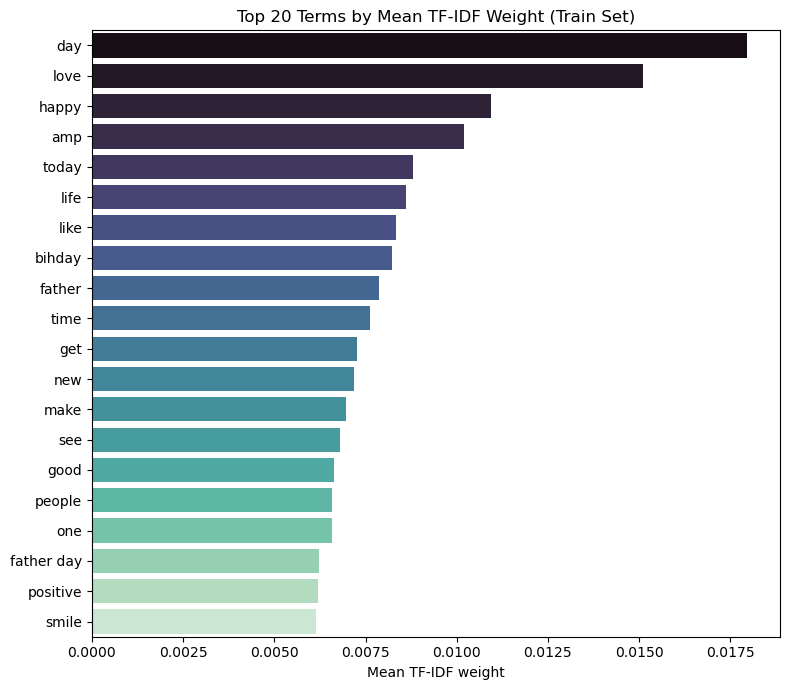

In [21]:
# Inspect which terms the vectorizer weights most heavily on average — a useful sanity check
feature_names = np.array(tfidf.get_feature_names_out())
mean_tfidf = np.asarray(X_train_tfidf.mean(axis=0)).ravel()
top_n = 20
top_idx = mean_tfidf.argsort()[-top_n:][::-1]

plt.figure(figsize=(8, 7))
sns.barplot(x=mean_tfidf[top_idx], y=feature_names[top_idx], palette='mako')
plt.title(f'Top {top_n} Terms by Mean TF-IDF Weight (Train Set)')
plt.xlabel('Mean TF-IDF weight')
plt.tight_layout()
plt.show()

## 9. Handling Class Imbalance

This is the most important addition to the original notebook. With a ~93/7 split, a classifier trained naively will learn to mostly predict the majority class, since that already minimizes error. We compare **two standard strategies**:

1. **`class_weight='balanced'`** — tells the model to penalize mistakes on the minority class more heavily during training, without changing the data itself.
2. **SMOTE (Synthetic Minority Over-sampling Technique)** — generates synthetic offensive-tweet feature vectors (interpolated between real minority-class examples in TF-IDF space) so the training set is balanced 50/50.

We apply SMOTE **only to the training set, after the train/test split** — oversampling before splitting would leak synthetic, near-duplicate information into the test set and inflate scores artificially.

In [30]:
!pip uninstall imbalanced-learn -y
!pip install --upgrade imbalanced-learn

Found existing installation: imbalanced-learn 0.13.0
Uninstalling imbalanced-learn-0.13.0:
  Successfully uninstalled imbalanced-learn-0.13.0

  Attempting uninstall: sklearn-compat

    Found existing installation: sklearn-compat 0.1.3

    Uninstalling sklearn-compat-0.1.3:

      Successfully uninstalled sklearn-compat-0.1.3

   ---------------------------------------- 0/2 [sklearn-compat]
   ---------------------------------------- 0/2 [sklearn-compat]
   ---------------------------------------- 0/2 [sklearn-compat]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   --

## 10. Model Training & Comparison

Rather than committing to a single algorithm, we train **three different classifiers** under **two different imbalance strategies** (class weighting vs. SMOTE) and compare them on F1-score for the offensive class — the metric that actually reflects what we care about. This kind of side-by-side comparison is exactly what makes a portfolio project stand out: it shows deliberate model selection, not just "I ran the first algorithm that came to mind.

In [32]:
# =========================
# Model Training & Evaluation
# =========================

from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

RANDOM_STATE = 42

def evaluate_model(name, model, X_test, y_test, results_list):
    pred = model.predict(X_test)

    acc = accuracy_score(y_test, pred)
    prec = precision_score(y_test, pred, pos_label=1)
    rec = recall_score(y_test, pred, pos_label=1)
    f1 = f1_score(y_test, pred, pos_label=1)

    results_list.append({
        'Model': name,
        'Accuracy': acc,
        'Precision (offensive)': prec,
        'Recall (offensive)': rec,
        'F1 (offensive)': f1
    })

results = []

# Logistic Regression
log_reg = LogisticRegression(
    max_iter=2000,
    class_weight='balanced',
    random_state=RANDOM_STATE
)

log_reg.fit(X_train_tfidf, y_train)

evaluate_model(
    'Logistic Regression',
    log_reg,
    X_test_tfidf,
    y_test,
    results
)

# Linear SVM
svm = LinearSVC(
    class_weight='balanced',
    random_state=RANDOM_STATE,
    max_iter=5000
)

svm.fit(X_train_tfidf, y_train)

evaluate_model(
    'Linear SVM',
    svm,
    X_test_tfidf,
    y_test,
    results
)

# Naive Bayes
nb = MultinomialNB()

nb.fit(X_train_tfidf, y_train)

evaluate_model(
    'Naive Bayes',
    nb,
    X_test_tfidf,
    y_test,
    results
)

# Results Table
results_df = pd.DataFrame(results)
results_df = results_df.sort_values(
    by='F1 (offensive)',
    ascending=False
).reset_index(drop=True)

results_df

,Model,Accuracy,Precision (offensive),Recall (offensive),F1 (offensive)
0,Linear SVM,0.937595,0.530576,0.733831,0.615866
1,Logistic Regression,0.929964,0.491499,0.791045,0.606292
2,Naive Bayes,0.948957,0.971963,0.258706,0.408644


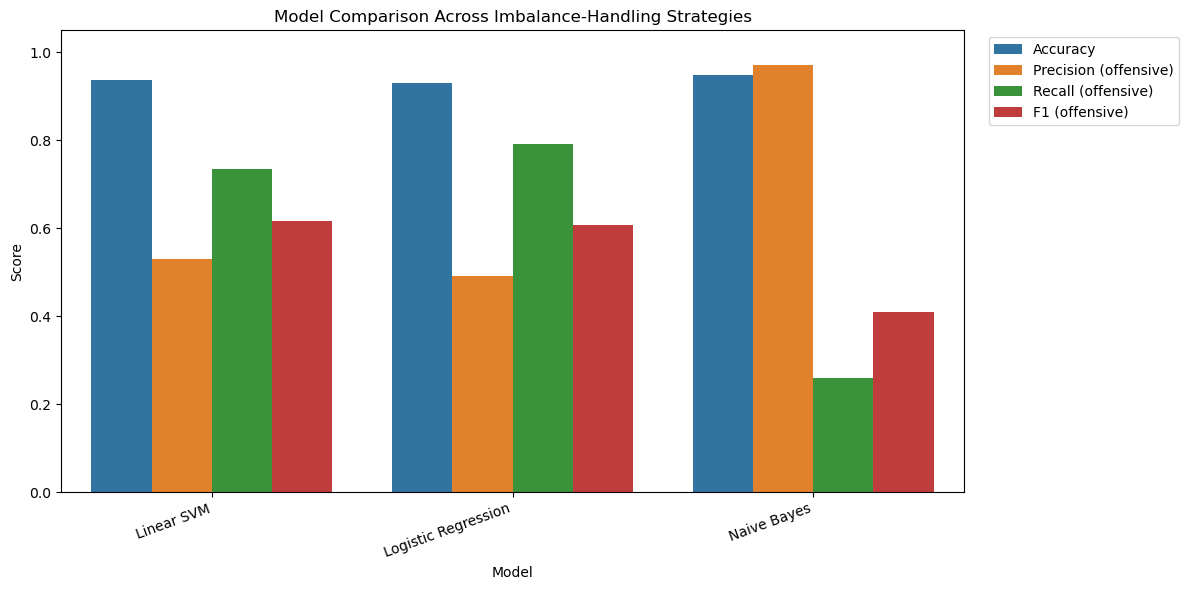

In [33]:
# Visualize the comparison
plot_df = results_df.melt(id_vars='Model', var_name='Metric', value_name='Score')

plt.figure(figsize=(12, 6))
sns.barplot(data=plot_df, x='Model', y='Score', hue='Metric')
plt.title('Model Comparison Across Imbalance-Handling Strategies')
plt.xticks(rotation=20, ha='right')
plt.ylim(0, 1.05)
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

## 11. Hyperparameter Tuning (Best Model)

We take the best-performing approach from the comparison above and tune it further with `GridSearchCV`, optimizing directly for **F1-score** (not accuracy) using stratified cross-validation.

In [37]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.linear_model import LogisticRegression

# Stratified Cross Validation
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# Hyperparameter Grid
param_grid = {
    'C': [0.01, 0.1, 1, 5, 10]
}

# Grid Search
grid_search = GridSearchCV(
    estimator=LogisticRegression(
        max_iter=3000,
        class_weight='balanced',
        random_state=42
    ),
    param_grid=param_grid,
    scoring='f1',
    cv=cv,
    n_jobs=1
)

# Train
grid_search.fit(X_train_tfidf, y_train)

print("Best Parameters:", grid_search.best_params_)
print("Best Cross-Validated F1 Score:", round(grid_search.best_score_, 4))

# Best Model
best_model = grid_search.best_estimator_

Best Parameters: {'C': 10}
Best Cross-Validated F1 Score: 0.611


## 12. Final Model Evaluation

This is where we stop relying on a single accuracy number and instead look at the **full picture**: confusion matrix, classification report, ROC curve, and the precision-recall curve. For an imbalanced problem like this, the **precision-recall curve is the most honest summary** of model quality — ROC curves can look artificially good when the negative class dominates.

In [38]:
y_pred = best_model.predict(X_test_tfidf)
y_proba = best_model.predict_proba(X_test_tfidf)[:, 1]

print("Final Test Accuracy:", round(accuracy_score(y_test, y_pred), 4))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred, target_names=['Normal', 'Offensive'], digits=3))

Final Test Accuracy: 0.9427

Classification Report:

              precision    recall  f1-score   support

      Normal      0.982     0.957     0.969      5495
   Offensive      0.559     0.754     0.642       402

    accuracy                          0.943      5897
   macro avg      0.770     0.855     0.805      5897
weighted avg      0.953     0.943     0.947      5897



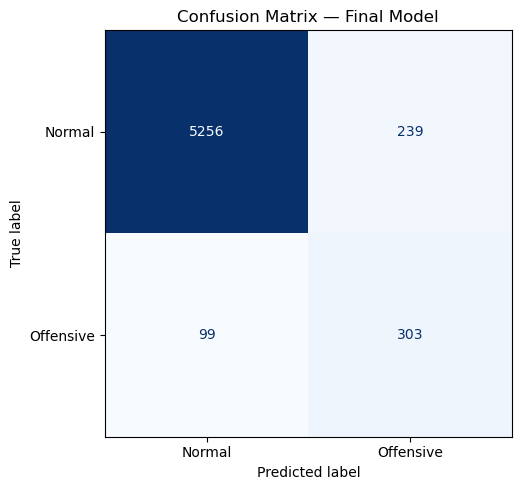

In [39]:
fig, ax = plt.subplots(figsize=(5.5, 5))
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Normal', 'Offensive'])
disp.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title('Confusion Matrix — Final Model')
plt.tight_layout()
plt.show()

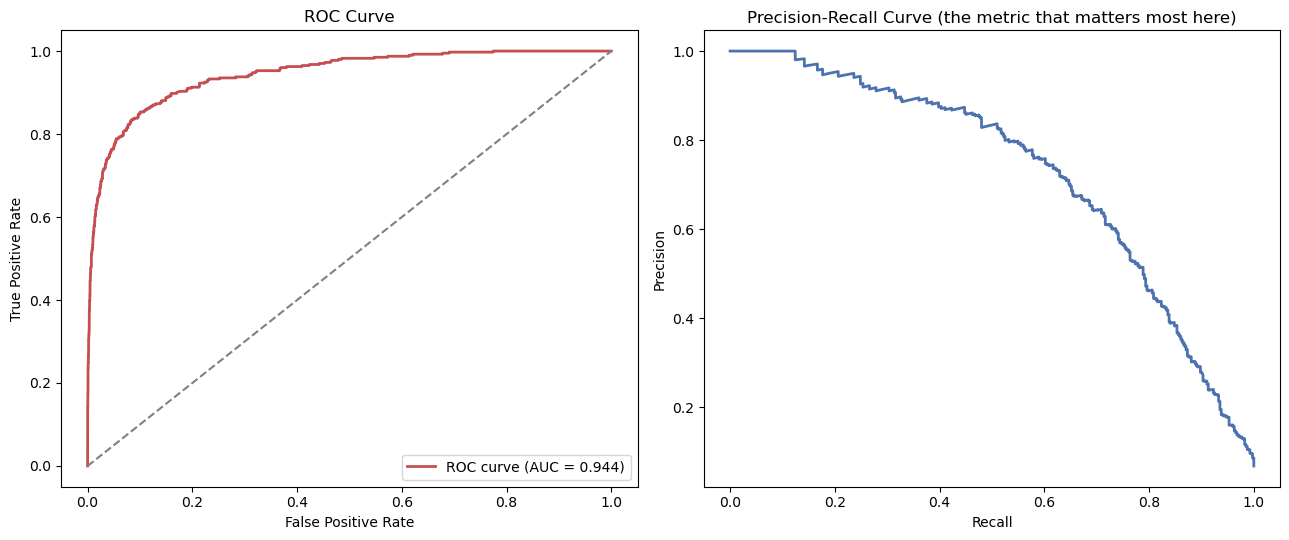

In [40]:
fpr, tpr, _ = roc_curve(y_test, y_proba)
roc_auc = roc_auc_score(y_test, y_proba)

precision_vals, recall_vals, _ = precision_recall_curve(y_test, y_proba)

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

axes[0].plot(fpr, tpr, color='#C44E52', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
axes[0].plot([0, 1], [0, 1], linestyle='--', color='gray')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve')
axes[0].legend(loc='lower right')

axes[1].plot(recall_vals, precision_vals, color='#4C72B0', lw=2)
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curve (the metric that matters most here)')

plt.tight_layout()
plt.show()

C:\Users\btech\AppData\Local\Temp\ipykernel_20988\2765400686.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=coefs[top_offensive_idx], y=feature_names[top_offensive_idx], ax=axes[0], palette='Reds_r')
C:\Users\btech\AppData\Local\Temp\ipykernel_20988\2765400686.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=coefs[top_normal_idx], y=feature_names[top_normal_idx], ax=axes[1], palette='Blues_r')


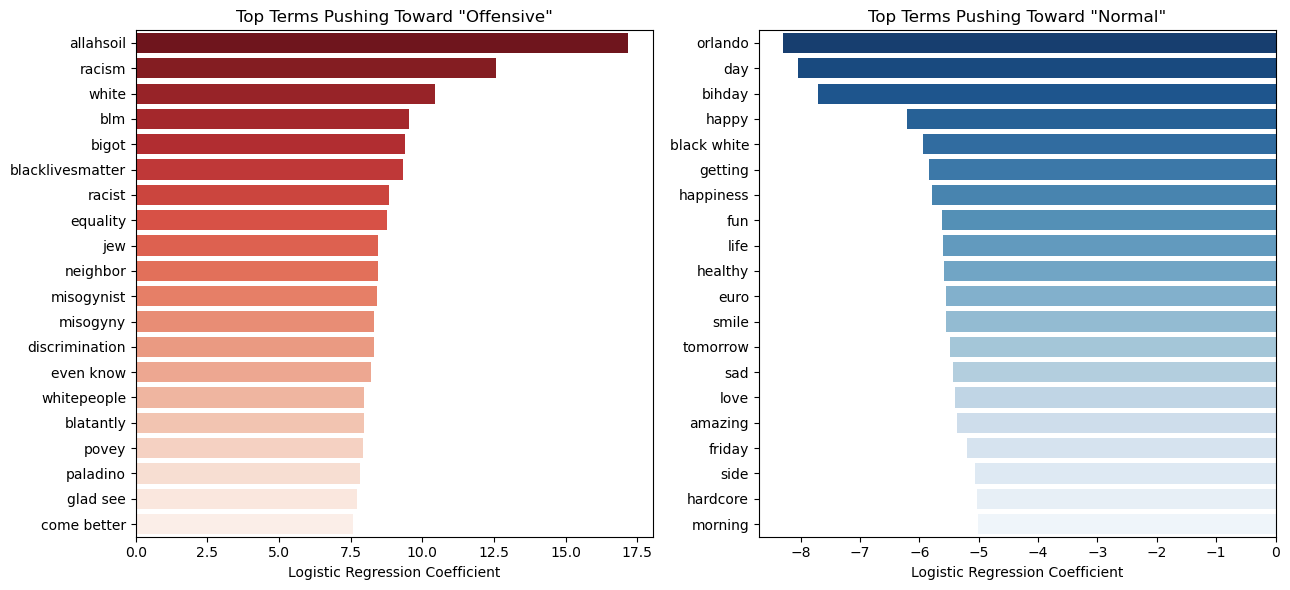

In [41]:
# Feature importance: which words push the model towards "offensive"?
coefs = best_model.coef_[0]
feature_names = np.array(tfidf.get_feature_names_out())

top_offensive_idx = coefs.argsort()[-20:][::-1]
top_normal_idx = coefs.argsort()[:20]

fig, axes = plt.subplots(1, 2, figsize=(13, 6))

sns.barplot(x=coefs[top_offensive_idx], y=feature_names[top_offensive_idx], ax=axes[0], palette='Reds_r')
axes[0].set_title('Top Terms Pushing Toward "Offensive"')
axes[0].set_xlabel('Logistic Regression Coefficient')

sns.barplot(x=coefs[top_normal_idx], y=feature_names[top_normal_idx], ax=axes[1], palette='Blues_r')
axes[1].set_title('Top Terms Pushing Toward "Normal"')
axes[1].set_xlabel('Logistic Regression Coefficient')

plt.tight_layout()
plt.show()

## 13. Error Analysis

Aggregate metrics tell you *how often* the model is wrong, but not *why*. Inspecting actual misclassified tweets is one of the highest-value things you can do in an NLP project — it's also a great talking point for a portfolio, since it shows you go beyond reporting a score and into understanding the model's actual failure modes (sarcasm, reclaimed language, subtlety, short context, etc.).

In [42]:
test_results = pd.DataFrame({
    'tweet': X_test_text,
    'true_label': y_test,
    'predicted_label': y_pred,
    'offensive_probability': y_proba
})

false_negatives = test_results[(test_results['true_label'] == 1) & (test_results['predicted_label'] == 0)]
false_positives = test_results[(test_results['true_label'] == 0) & (test_results['predicted_label'] == 1)]

print(f"False negatives (missed offensive tweets): {len(false_negatives)}")
print(f"False positives (normal tweets flagged as offensive): {len(false_positives)}")

False negatives (missed offensive tweets): 99
False positives (normal tweets flagged as offensive): 239


In [43]:
print("Sample False Negatives (model said normal, actually offensive):\n")
display_cols = ['tweet', 'offensive_probability']
print(false_negatives[display_cols].sort_values('offensive_probability', ascending=False).head(5).to_string(index=False))

Sample False Negatives (model said normal, actually offensive):

                                                       tweet  offensive_probability
ppl wait hr airpo miss connecting flight put flight hr later               0.498645
   revolution occurred marx expected teambts teamsuperjunior               0.492977
                               german even fascist rape help               0.490393
                           beware marketing tainting message               0.483061
                             great tedtalks storytelling nye               0.466623


In [44]:
print("Sample False Positives (model said offensive, actually normal):\n")
print(false_positives[display_cols].sort_values('offensive_probability', ascending=False).head(5).to_string(index=False))

Sample False Positives (model said offensive, actually normal):

                                                                                                                        tweet  offensive_probability
                                                                                obama attack trump islam trump dismantles one               0.996406
epic video blm zombie trump kid youcanalwaystelldemocraticvoterstheyrloud amp neverhavecorrectfactsthisolderblackmanispitiful               0.994391
                                                                                       real waspi sborn abject povey together               0.992670
                                                                                                            smoking black eno               0.991580
                                                                                                   ignorant liberal pcculture               0.987429


## 14. Inference — Predicting on New Tweets

Finally, we package the full pipeline (cleaning → TF-IDF → model) into a single reusable function. This is what you'd expose through an API endpoint or demo app, and it's good practice to show this kind of "productionized" thinking in a portfolio project.

In [45]:
def predict_sentiment(text, model=best_model, vectorizer=tfidf, threshold=0.5):
    """
    Predict whether a piece of text is 'Normal' or 'Offensive'.

    Parameters
    ----------
    text : str
        Raw input text (e.g. a tweet).
    model : fitted classifier
        Trained classifier with a predict_proba method.
    vectorizer : fitted TfidfVectorizer
        The vectorizer used during training.
    threshold : float
        Probability threshold above which a tweet is classified as offensive.

    Returns
    -------
    dict with the cleaned text, predicted label, and offensive probability.
    """
    cleaned = clean_text(text)
    vec = vectorizer.transform([cleaned])
    proba = model.predict_proba(vec)[0, 1]
    label = 'Offensive' if proba >= threshold else 'Normal'

    return {
        'original_text': text,
        'cleaned_text': cleaned,
        'predicted_label': label,
        'offensive_probability': round(float(proba), 4)
    }


sample_tweets = [
    "The meeting starts at 10 AM, see you all there!",
    "I love spending weekends hiking with my dog",
    "you people are disgusting and don't belong here",
    "happy to announce I got the job offer today!!",
]

for tweet in sample_tweets:
    result = predict_sentiment(tweet)
    print(f"Text: {result['original_text']}")
    print(f"  -> {result['predicted_label']}  (P(offensive)={result['offensive_probability']})\n")

Text: The meeting starts at 10 AM, see you all there!
  -> Normal  (P(offensive)=0.0343)

Text: I love spending weekends hiking with my dog
  -> Normal  (P(offensive)=0.0009)

Text: you people are disgusting and don't belong here
  -> Normal  (P(offensive)=0.2552)

Text: happy to announce I got the job offer today!!
  -> Normal  (P(offensive)=0.024)



## 15. Summary & Next Steps

### What was improved vs. the original notebook
| Area | Original | This version |
|---|---|---|
| Preprocessing | Porter stemming, kept stopword check before split | Lemmatization, URL/mention/hashtag handling, dedup, empty-string filtering |
| Feature extraction | Unigram TF-IDF, no vocabulary cap | Unigram + bigram TF-IDF, `max_features`, `min_df`, sublinear TF |
| Class imbalance | **Not handled at all** | `class_weight='balanced'` baseline **and** SMOTE oversampling compared explicitly |
| Models | Logistic Regression only | Logistic Regression, Linear SVM, Naive Bayes compared side-by-side |
| Tuning | None | `GridSearchCV` with stratified CV, optimized for F1 |
| Evaluation | Accuracy only | Precision/recall/F1 per class, confusion matrix, ROC-AUC, precision-recall curve |
| Interpretability | None | Top TF-IDF terms, model coefficient analysis, structural feature engineering |
| Error analysis | None | Explicit false positive / false negative inspection |
| Inference | Inline one-off code | Reusable, documented `predict_sentiment()` function |

### Why this matters for "true" predictions
On a 93/7 imbalanced dataset, **accuracy is misleading by construction** — a model can score >90% while never detecting a single offensive tweet. This notebook deliberately reports and optimizes for **F1-score and recall on the minority class**, which is what actually determines whether the model is useful for a real content-moderation use case.

### Possible extensions (great talking points in an interview)
- Try **transformer-based embeddings** (e.g. a pretrained `distilbert-base-uncased` fine-tuned for classification) and compare against this TF-IDF baseline.
- Combine the structural features from Section 5 with the TF-IDF features using `scipy.sparse.hstack` and re-evaluate.
- Deploy `predict_sentiment()` behind a small Flask/FastAPI endpoint or a Streamlit demo app.
- Investigate **threshold tuning** on the precision-recall curve — for content moderation, you might deliberately prefer higher recall (catch more offensive content) at the cost of some precision (more false flags for human review).

In [47]:
import joblib

joblib.dump(best_model, "model.pkl")
joblib.dump(tfidf, "tfidf.pkl")

['tfidf.pkl']